In [4]:
#we are importing numpy(scientific computing ) and matplotlib (ploting)
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split , KFold

In [5]:
#Generate random data for dogs and cats 
np.random.seed(0) # for reproducibility 

In [6]:
# Dogs : higher ear flappiness , lower whisker length 
dogs_whisker_length = np.random.normal(loc=5,scale=1,size=10)
dogs_ear_flappiness_index = np.random.normal(loc=8,scale=1,size=10)


In [7]:
dogs_whisker_length,dogs_ear_flappiness_index

(array([6.76405235, 5.40015721, 5.97873798, 7.2408932 , 6.86755799,
        4.02272212, 5.95008842, 4.84864279, 4.89678115, 5.4105985 ]),
 array([8.14404357, 9.45427351, 8.76103773, 8.12167502, 8.44386323,
        8.33367433, 9.49407907, 7.79484174, 8.3130677 , 7.14590426]))

In [8]:
#Cats : lower ear flappiness index , higher whisker length 
cats_whisker_length = np.random.normal(loc=8,scale=1,size=10)
cats_ear_flappiness_index = np.random.normal(loc=5,scale=1,size=10)

In [9]:
cats_whisker_length,cats_ear_flappiness_index

(array([ 5.44701018,  8.6536186 ,  8.8644362 ,  7.25783498, 10.26975462,
         6.54563433,  8.04575852,  7.81281615,  9.53277921,  9.46935877]),
 array([5.15494743, 5.37816252, 4.11221425, 3.01920353, 4.65208785,
        5.15634897, 6.23029068, 6.20237985, 4.61267318, 4.69769725]))

In [10]:
#combine data 
dogs_data = np.vstack((dogs_whisker_length, dogs_ear_flappiness_index)).T
cats_data = np.vstack((cats_whisker_length,cats_ear_flappiness_index)).T
data = np.vstack((dogs_data, cats_data))
labels= np.hstack((np.zeros(len(dogs_data)),np.ones(len(cats_data))))


In [11]:
dogs_data

array([[6.76405235, 8.14404357],
       [5.40015721, 9.45427351],
       [5.97873798, 8.76103773],
       [7.2408932 , 8.12167502],
       [6.86755799, 8.44386323],
       [4.02272212, 8.33367433],
       [5.95008842, 9.49407907],
       [4.84864279, 7.79484174],
       [4.89678115, 8.3130677 ],
       [5.4105985 , 7.14590426]])

In [12]:
cats_data

array([[ 5.44701018,  5.15494743],
       [ 8.6536186 ,  5.37816252],
       [ 8.8644362 ,  4.11221425],
       [ 7.25783498,  3.01920353],
       [10.26975462,  4.65208785],
       [ 6.54563433,  5.15634897],
       [ 8.04575852,  6.23029068],
       [ 7.81281615,  6.20237985],
       [ 9.53277921,  4.61267318],
       [ 9.46935877,  4.69769725]])

In [13]:
labels

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1., 1., 1., 1.,
       1., 1., 1.])

In [14]:
data

array([[ 6.76405235,  8.14404357],
       [ 5.40015721,  9.45427351],
       [ 5.97873798,  8.76103773],
       [ 7.2408932 ,  8.12167502],
       [ 6.86755799,  8.44386323],
       [ 4.02272212,  8.33367433],
       [ 5.95008842,  9.49407907],
       [ 4.84864279,  7.79484174],
       [ 4.89678115,  8.3130677 ],
       [ 5.4105985 ,  7.14590426],
       [ 5.44701018,  5.15494743],
       [ 8.6536186 ,  5.37816252],
       [ 8.8644362 ,  4.11221425],
       [ 7.25783498,  3.01920353],
       [10.26975462,  4.65208785],
       [ 6.54563433,  5.15634897],
       [ 8.04575852,  6.23029068],
       [ 7.81281615,  6.20237985],
       [ 9.53277921,  4.61267318],
       [ 9.46935877,  4.69769725]])

In [15]:
#split data into training and testing sets 
X_train, X_test , y_train, y_test = train_test_split(data,labels, test_size=0.2, random_state=42)

In [16]:
X_test

array([[6.76405235, 8.14404357],
       [7.81281615, 6.20237985],
       [6.54563433, 5.15634897],
       [5.40015721, 9.45427351]])

In [17]:
X_train

array([[ 4.89678115,  8.3130677 ],
       [ 4.02272212,  8.33367433],
       [ 8.6536186 ,  5.37816252],
       [ 7.2408932 ,  8.12167502],
       [ 9.53277921,  4.61267318],
       [ 8.04575852,  6.23029068],
       [ 7.25783498,  3.01920353],
       [ 5.97873798,  8.76103773],
       [ 5.4105985 ,  7.14590426],
       [ 9.46935877,  4.69769725],
       [ 6.86755799,  8.44386323],
       [ 8.8644362 ,  4.11221425],
       [ 4.84864279,  7.79484174],
       [ 5.44701018,  5.15494743],
       [10.26975462,  4.65208785],
       [ 5.95008842,  9.49407907]])

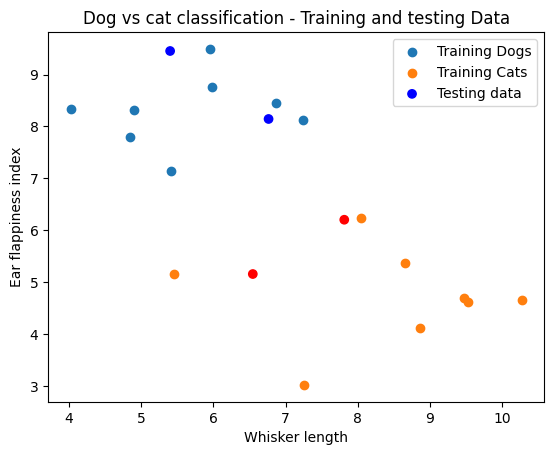

In [18]:
#plot the training and testing data 
plt.scatter(X_train[y_train==0][:, 0], X_train[y_train==0][: ,1], label= "Training Dogs")
plt.scatter(X_train[y_train==1][:, 0], X_train[y_train==1][: ,1], label= "Training Cats")
plt .scatter(X_test[:,0], X_test[:,1],c=y_test,cmap='bwr',label = "Testing data")
plt.xlabel("Whisker length")
plt.ylabel("Ear flappiness index")
plt.title("Dog vs cat classification - Training and testing Data")
plt.legend()
plt.show()


In [21]:
#impelemt the random classification algorithm ,d = size of no of features(inthis case d=2 coz we have 2 features whisker lenth and flappiness index )
 
def random_linear_classifier (data_dogs, data_cats, k,d ):
    best_error=float('inf')
    best_theta= None
    best_theta0= None

    for _ in range(k):
        theta = np.random.normal(size=d)
        theta0= np.random.normal()
        error = compute_error(data_dogs,data_cats,theta,theta0)

        if error<best_error:
            best_error= error
            best_theta= theta
            best_theta0= theta0
    return best_theta, best_theta0 ,best_error

#compute error function 
def compute_error(data_dogs, data_cats,theta, theta0):
    error =0 
    for x_dog in data_dogs :
        if np.dot(theta, x_dog) + theta0 <=0:
            error +=1
    for x_cat in data_cats :
        if np.dot(theta, x_cat) + theta0 >0:
            error +=1
    return error


        

In [20]:
# RUN linear classifier algorithm on training data
k=100
d=2
best_theta_train , best_theta0_train , train_error = random_linear_classifier(X_train[y_train==0],X_train[y_train==1],k,d)

In [22]:
best_theta0_train, best_theta_train

(-0.40317694697317963, array([-1.07075262,  1.05445173]))

In [23]:
#plot the decision  boundary on training data 
x_vals_train = np.linspace(2,10,100)
y_vals_train= (-best_theta_train[0]/best_theta_train[1])*x_vals_train - (best_theta0_train/best_theta_train[1])

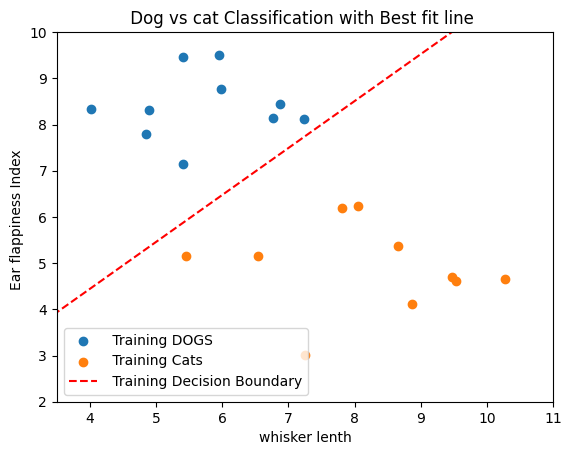

In [24]:
plt.scatter(dogs_whisker_length, dogs_ear_flappiness_index , label =" Training DOGS")
plt.scatter(cats_whisker_length, cats_ear_flappiness_index, label =' Training Cats')
plt.plot(x_vals_train,y_vals_train,color='red', linestyle ='--', label =" Training Decision Boundary")
# Set same limits for x and y axes 
plt.xlim([3.5,11])
plt.ylim([2,10])

plt.xlabel("whisker lenth")
plt.ylabel("Ear flappiness Index ")
plt.title (" Dog vs cat Classification with Best fit line  ")
plt.legend()
plt.show()


In [25]:
print(f"Training Error : {train_error}")

Training Error : 0


In [26]:
#compute testing error 
test_error =compute_error(X_test[y_test==0],X_test[y_test==1],best_theta_train,best_theta0_train)
print(f"Testing Error :{test_error}")

Testing Error :0
